<a href="https://colab.research.google.com/github/sarmuh/Diabetes_Predict_ML/blob/main/Diabetes_Predict_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import sklearn
import imblearn

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,jaccard_score


from imblearn.over_sampling import SMOTE

In [3]:
url = "https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv"
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


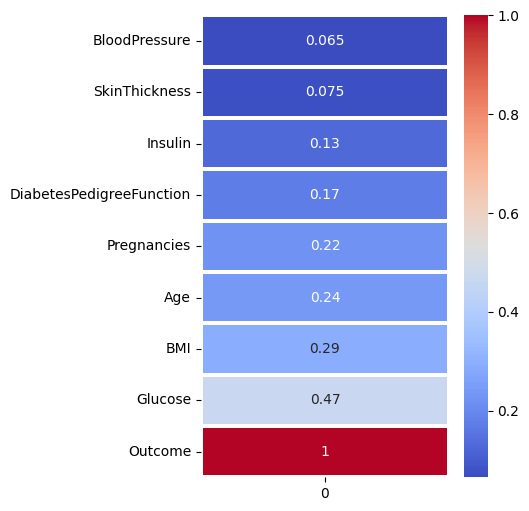

In [6]:
plt.figure(figsize=(4,6))

sns.heatmap(df.corrwith(df['Outcome']).sort_values().to_frame(),annot=True,linewidths=1.5,cmap='coolwarm')
plt.show()

In [7]:
df[(df['Glucose']==0) | (df['BloodPressure']==0) | (df['SkinThickness']==0) | (df['Insulin']==0)| (df['BMI']==0)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
er_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[er_cols] = df[er_cols].replace(0,np.nan)
df.isna().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [10]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=788,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [11]:
y_test.value_counts()

,count
Outcome,
0,93
1,61


In [12]:
knn_imputer = KNNImputer(n_neighbors=7)
X_train_clean = knn_imputer.fit_transform(X_train)
X_test_clean = knn_imputer.transform(X_test)

In [13]:
np.isnan(X_train_clean).sum(),np.isnan(X_test_clean).sum()

(np.int64(0), np.int64(0))

In [14]:
X_train_clean = pd.DataFrame(X_train_clean,columns=X_train.columns)
X_test_clean = pd.DataFrame(X_test_clean,columns=X_test.columns)

In [15]:
display(X_train_clean.sample(7)),display(X_test_clean.sample(7))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
161,2.0,68.0,62.0,13.000000,15.000000,20.1,0.257,23.0
47,3.0,74.0,68.0,28.000000,45.000000,29.7,0.293,23.0
112,5.0,116.0,74.0,22.000000,98.714286,25.6,0.201,30.0
247,5.0,106.0,82.0,30.000000,166.142857,39.5,0.286,38.0
101,3.0,99.0,80.0,11.000000,64.000000,19.3,0.284,30.0
606,1.0,95.0,66.0,13.000000,38.000000,19.6,0.334,25.0
198,0.0,104.0,76.0,20.285714,79.142857,18.4,0.582,27.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
13,0.0,117.0,78.0,32.428571,146.142857,33.8,0.932,44.0
147,7.0,103.0,66.0,32.000000,121.142857,39.1,0.344,31.0
106,3.0,96.0,78.0,39.000000,103.857143,37.3,0.238,40.0
142,3.0,158.0,64.0,13.000000,387.000000,31.2,0.295,24.0
43,3.0,111.0,62.0,21.428571,99.571429,22.6,0.142,21.0
10,6.0,183.0,94.0,26.714286,233.142857,40.8,1.461,45.0
115,6.0,92.0,62.0,32.000000,126.000000,32.0,0.085,46.0


(None, None)

In [16]:
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train_clean,y_train)
y_train.value_counts(),y_train_sm.value_counts()

(Outcome
 0    407
 1    207
 Name: count, dtype: int64,
 Outcome
 1    407
 0    407
 Name: count, dtype: int64)

In [17]:
model = RandomForestClassifier()
parm = {
    'n_estimators':[100,200,300,500],
    'max_samples':[0.7,0.8,0.9]
}

Hal_search = HalvingGridSearchCV(estimator=model,param_grid=parm,random_state=42,cv=3,n_jobs=-1,verbose=1,scoring='f1',factor=2)
Hal_search.fit(X_train_sm,y_train_sm)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 101
max_resources_: 814
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 12
n_resources: 101
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 6
n_resources: 202
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 2
n_candidates: 3
n_resources: 404
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 3
n_candidates: 2
n_resources: 808
Fitting 3 folds for each of 2 candidates, totalling 6 fits


HalvingGridSearchCV(cv=3, estimator=RandomForestClassifier(), factor=2,
                    n_jobs=-1,
                    param_grid={'max_samples': [0.7, 0.8, 0.9],
                                'n_estimators': [100, 200, 300, 500]},
                    random_state=42, scoring='f1', verbose=1)

In [18]:
Hal_search.best_params_

{'max_samples': 0.8, 'n_estimators': 500}

In [19]:
Hal_search.best_score_

np.float64(0.8132751815405062)

In [20]:
predict = Hal_search.predict(X_test_clean)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80        93
           1       0.68      0.77      0.72        61

    accuracy                           0.77       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.77      0.77      0.77       154



In [35]:
jaccard_score(y_test,predict)

np.float64(0.5662650602409639)

In [21]:
confusion_matrix(y_test,predict)

array([[71, 22],
       [14, 47]])

In [ ]:
import cudf

X_train_gpu = cudf.DataFrame(X_train_sm)
y_train_gpu = cudf.Series(y_train_sm)

X_test_gpu = cudf.DataFrame(X_test_clean)
y_test_gpu = cudf.Series(y_test)


n_iterations: 4
n_required_iterations: 5
n_possible_iterations: 4
min_resources_: 12
max_resources_: 814
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 100
n_resources: 12
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 34
n_resources: 36
Fitting 3 folds for each of 34 candidates, totalling 102 fits
----------
iter: 2
n_candidates: 12
n_resources: 108
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 324
Fitting 3 folds for each of 4 candidates, totalling 12 fits

🚀 XGBoost topgan Mutlaq G'olib Parametrlar:
{'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

🏆 XGBoost'ning Test (Imtihon) Aniqligi: 0.7727272727272727

📊 Batafsil Hisobot:
               precision    recall  f1-score   support

           0       0.85      0.75      0.80        93
           1       0.68      0.80   

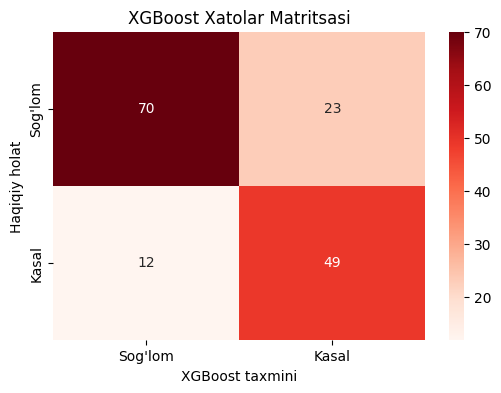

In [26]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)


xgb_params = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}


xgb_search = HalvingRandomSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_candidates=100,
    factor=3,
    scoring='accuracy',
    cv=3,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train_sm, y_train_sm)

print("\n G'olib Parametrlar:")
print(xgb_search.best_params_)


best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_clean)

print("\n XGBoost'ning Test (Imtihon) Aniqligi:", accuracy_score(y_test, y_pred_xgb))
print("\n Batafsil Hisobot:\n", classification_report(y_test, y_pred_xgb))


cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Sog\'lom', 'Kasal'],
            yticklabels=['Sog\'lom', 'Kasal'])
plt.ylabel("Haqiqiy holat")
plt.xlabel("XGBoost taxmini")
plt.title("XGBoost Xatolar Matritsasi")
plt.show()

In [36]:
jaccard_score(y_test, y_pred_xgb)

np.float64(0.573170731707317)